In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM010_M_L-rotated2.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM002_M_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM010_M_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM013_F_R-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM011_F_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM019_F_R-rotated2.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM020_F_L-rotated1.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabe

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

In [9]:
DATA_DIR = '/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"  # "Control Group" vs "DM Group"
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1444 files belonging to 2 classes.
Using 1156 files for training.
Found 1444 files belonging to 2 classes.
Using 288 files for validation.
Class names: ['Control Group', 'DM Group']


In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])


base_model = keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)

x = keras.applications.resnet50.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary() 

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      2,049 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
# Phase 1: Train the Head (Warm-up)
print("--- Phase 1: Training Classification Head ---")
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30)

print("\n--- Phase 2: Unfreezing Top Layers for Fine-Tuning ---")
base_model.trainable = True

# Freeze everything except the top 20 layers of ResNet50
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=3, 
    restore_best_weights=True)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping])

--- Phase 1: Training Classification Head ---
Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 222ms/step - accuracy: 0.6869 - loss: 0.5839 - val_accuracy: 0.8056 - val_loss: 0.4264
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - accuracy: 0.8123 - loss: 0.3882 - val_accuracy: 0.8507 - val_loss: 0.3357
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 151ms/step - accuracy: 0.8573 - loss: 0.3151 - val_accuracy: 0.8819 - val_loss: 0.3007
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.8728 - loss: 0.2983 - val_accuracy: 0.8715 - val_loss: 0.2784
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.8772 - loss: 0.2780 - val_accuracy: 0.8958 - val_loss: 0.2544
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.8858 - loss: 0.2542 - val_accuracy: 0.9028 - val_loss: 0.2308
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.9074 - loss: 0.2237 - val_accuracy: 0.9062 - val_loss: 0.2285
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - acc

=== Validation Performance Metrics ===
Accuracy:      98.61%
Precision:     100.00%  (Out of all predicted DM, how many were actually DM?)
Recall/Sens:   97.42%  (Out of all actual DM, how many did we catch?)
F1-Score:      98.69%  (Harmonic mean of Precision and Recall)



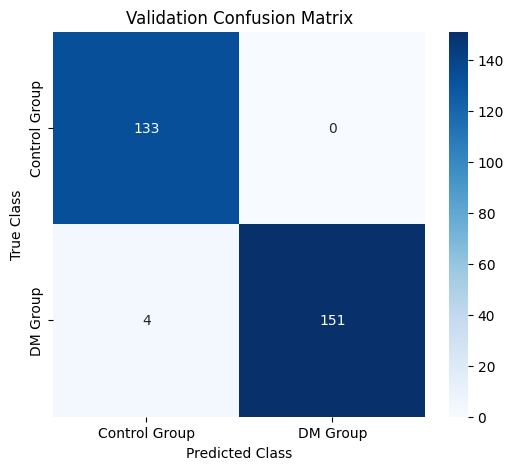

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

all_labels = []
all_preds = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = (preds > 0.5).astype(int)
    
    all_labels.extend(labels.numpy().flatten())
    all_preds.extend(pred_labels.flatten())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

accuracy = np.mean(all_labels == all_preds)
tp = np.sum((all_labels == 1) & (all_preds == 1))
fp = np.sum((all_labels == 0) & (all_preds == 1))
fn = np.sum((all_labels == 1) & (all_preds == 0))
tn = np.sum((all_labels == 0) & (all_preds == 0))

precision = tp / (tp + fp + 1e-7)
recall = tp / (tp + fn + 1e-7)  
f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)

print("=== Validation Performance Metrics ===")
print(f"Accuracy:      {accuracy:.2%}")
print(f"Precision:     {precision:.2%}  (Out of all predicted DM, how many were actually DM?)")
print(f"Recall/Sens:   {recall:.2%}  (Out of all actual DM, how many did we catch?)")
print(f"F1-Score:      {f1_score:.2%}  (Harmonic mean of Precision and Recall)")
print("======================================\n")

cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

